# 09. Forward-Model Feasibility and Route Decision

**Scientific question.** Can the current one-ALN-cortical-node plus
one-thalamic-node model generate a physically declared `EEG Fpz-Cz`
observable, or does Route 2 still require new spatial and source
assumptions?

This notebook is an audit, not a forward-model implementation. It
performs no `Hz -> uV` scaling, no simulation-bank generation and no
SNPE training. A high correlation after z-scoring or PSD
normalization remains **shape-level screening**, not EEG measurement
validation.

The audit distinguishes:

- a **model state**, such as population firing rate or adaptation;
- a **primary EEG source**, normally requiring a physical
  current-dipole definition;
- a **lead field**, which projects located and oriented sources
  through a volume conductor to sensor potentials;
- the `Fpz-Cz` **bipolar reference**, applied only after separate
  sensor potentials exist.

Primary references:

- [Cakan & Obermayer (2020), ALN mean-field model](https://doi.org/10.1371/journal.pcbi.1007822)
- [MNE `make_forward_solution`](https://mne.tools/stable/generated/mne.make_forward_solution.html)
- [MNE head model and forward tutorial](https://mne.tools/stable/auto_tutorials/forward/30_forward.html)
- [Hallez et al. (2007), EEG forward-problem review](https://pmc.ncbi.nlm.nih.gov/articles/PMC2234413/)
- [Mosher et al. (1999), EEG/MEG forward solutions](https://pubmed.ncbi.nlm.nih.gov/10097460/)


## 1. Environment, immutable inputs, and audit boundary

This block locates the repository without machine-specific paths,
records the actual `neurolib` interpreter, hashes notebooks 01-08,
and reloads the Route-2 NO-GO decision from notebook 08. No raw EEG or
simulator arrays are loaded here.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import os
from pathlib import Path
import platform
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from jupyter_client.kernelspec import KernelSpecManager

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / ".git").exists() and (PROJECT_ROOT / "S4_sbi").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate sleep_loop repository root")
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from sleep_sbi.forward_model_feasibility import (
    SCHEMA_VERSION,
    MeasurementContractError,
    apply_measurement_model,
    calibration_leakage_matrix,
    citation_table,
    leadfield_requirement_matrix,
    measurement_contract_components,
    protected_notebook_paths,
    route_decision_matrix,
    single_source_rank_audit,
    source_candidate_decisions,
    validate_measurement_declaration,
)

OUTPUT_DIR = PROJECT_ROOT / "S4_sbi" / "results" / "forward_model_feasibility_route_decision"
FIGURE_DIR = OUTPUT_DIR / "figures"
HTML_DIR = PROJECT_ROOT / "S4_sbi" / "results" / "overnight_observation_ablation" / "html"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
HTML_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PATH = PROJECT_ROOT / "S4_sbi" / "notebooks" / "09_Forward_Model_Feasibility_and_Route_Decision.ipynb"

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

protected_paths = protected_notebook_paths(PROJECT_ROOT)
protected_hashes_start = {
    path.relative_to(PROJECT_ROOT).as_posix(): sha256(path)
    for path in protected_paths
}

ksm = KernelSpecManager()
kernel_id = "python3"
kernel_display_name = ksm.get_kernel_spec(kernel_id).display_name
environment = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys_executable": sys.executable,
    "sys_prefix": sys.prefix,
    "python_version": platform.python_version(),
    "kernel_id": kernel_id,
    "kernel_display_name": kernel_display_name,
    "neurolib_version": importlib.metadata.version("neurolib"),
    "neurolib_source": str(Path(__import__("neurolib").__file__).resolve()),
    "schema_version": SCHEMA_VERSION,
}
assert environment["conda_environment"] == "neurolib"
assert "neurolib" in environment["sys_executable"].lower()

audit08_dir = PROJECT_ROOT / "S4_sbi" / "results" / "eeg_observation_mapping_audit"
route08 = json.loads((audit08_dir / "route_decision.json").read_text(encoding="utf-8"))
assert route08["recommended_route"] == "Route 2"
assert route08["route_1_shared_schema_go"] is False
display(pd.DataFrame([environment]))
print(f"Protected notebooks hashed: {len(protected_hashes_start)}")
print(f"Notebook-08 inherited gate: {route08['recommended_route']} / shared schema GO={route08['route_1_shared_schema_go']}")


,created_utc,conda_environment,sys_executable,sys_prefix,python_version,kernel_id,kernel_display_name,neurolib_version,neurolib_source,schema_version
0,2026-07-27T14:47:37.091314+00:00,neurolib,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,3.10.20,python3,Python 3 (ipykernel),0.6.1,D:\Year3_Mao_Projects\neurolib\neurolib\__init...,forward-model-feasibility-v0.1


Protected notebooks hashed: 11
Notebook-08 inherited gate: Route 2 / shared schema GO=False


## 2. Which ALN quantities are states, and which are intermediates?

`r_mean`, `I_mu`, synaptic mean/variance variables and excitatory
adaptation `I_A` are numerical states integrated by the ALN masses.
The historical project network only asked neurolib to record
`r_mean_EXC` and `r_mean_INH`; notebook 08 temporarily expanded
`output_vars` for auditing without changing the equations.

Population mean voltage is different: `voltage_lookup(...)` is
evaluated inside the excitatory derivative to update adaptation. It
is backed by the precomputed `V_mean_ss` transfer-function table but
is not a saved state. It can be reconstructed in a future audit if
`I_sigma` and all required coupling inputs are reconstructed. Even
then, membrane voltage is not automatically a current dipole.


,quantity,code_class,project_saved,native_unit,EEG_source_ready,evidence
0,r_mean_EXC / r_mean_INH,integrated state,True,1/ms; project converts to Hz,False,aln.py state_variable_names; V7 output_vars
1,I_mu EXC/INH,integrated state,False,mV/ms,False,"aln.py:414-421,577-606"
2,I_A EXC,integrated adaptation state,False,pA,False,"aln.py:414-421,535-547"
3,synaptic mean/variance states,integrated states,False,dimensionless/model-native,False,"aln.py:414-421,539-556"
4,population mean voltage,transfer-function intermediate,False,mV,False,"V_mean_ss and voltage_lookup, aln.py:234-246,3..."
5,TCR/TRN V,integrated thalamic states,False,mV,False,"thalamus.py:125-135,304-311"


,candidate,available_state,physical_meaning,units,directionality,spatial_location,dipole_interpretation,required_reconstruction,identifiability_risk,compatibility_with_lead_field,scientific_support,decision,evidence
0,cortical_r_mean_EXC,Yes; saved by the project,Excitatory-population firing rate,Hz after project kHz-to-Hz conversion,None,Abstract ALN cortical node; no coordinate or c...,No primary-current or dipole-moment definition,None for rate; a separate source model would b...,High: rate dynamics and measurement gain/sourc...,No: a lead field multiplies a declared current...,Strong as an ALN state; insufficient as scalp-...,Route-3 observable only; reject as direct Rout...,"models/s4_personalize_fig7_v7.py:226-227,913-924"
1,cortical_r_mean_INH,Yes; saved by the project,Inhibitory-population firing rate,Hz after project kHz-to-Hz conversion,None,Same abstract ALN cortical node,No dipole moment; inhibitory populations do no...,Separate source model and population geometry,High,No,Strong as an ALN state; insufficient as scalp-...,Route-3 diagnostic only,"neurolib/.../builder/aln.py:577-606,641-705"
2,equal_weight_E_minus_I_rate,Derived from two saved rates,Arbitrary equal-weight rate contrast,Hz,Sign comes from an analyst-chosen subtraction,Same abstract node,No calibrated relationship to aligned pyramida...,Physiological E/I weights and source geometry,"Very high: weights, gain, and theta can compen...",No,No project or literature calibration for equal...,Exclude from Route 2; shape-screening diagnost...,S4_sbi/src/sleep_sbi/eeg_observation_mapping_a...
3,equal_weight_E_plus_I_rate,Derived from two saved rates,Arbitrary equal-weight rate sum,Hz,None,Same abstract node,No dipole direction or physical source moment,Physiological weights and source geometry,Very high,No,No project calibration,Exclude from Route 2,S4_sbi/src/sleep_sbi/eeg_observation_mapping_a...
4,cortical_I_mu_EXC,"Yes; ALN state, audit-recorded",Mean effective current/drive state of the exci...,mV/ms in neurolib convention,None,Abstract cortical population,A temporal drive is not a vector current dipole,"Source-current density, patch geometry, and di...",High,"No, not without a source-to-dipole definition",Equation-level support as ALN dynamics,Route-2 research candidate only; not forward-r...,"neurolib/.../builder/aln.py:414-421,511-558"
5,cortical_I_mu_INH,"Yes; ALN state, audit-recorded",Mean effective current/drive state of the inhi...,mV/ms in neurolib convention,None,Abstract cortical population,Not a dipole source and lacks pyramidal-cell g...,"Source-current density, patch geometry, and or...",High,No,Equation-level support as ALN dynamics,Route-2 research diagnostic only,neurolib/.../builder/aln.py:577-705
6,cortical_adaptation_I_A,"Yes; ALN excitatory state, audit-recorded",Population adaptation-current state used in th...,pA in neurolib parameterization,No macroscopic orientation,Abstract cortical population,A cellular/population adaptation current is no...,"Population size, current density, laminar geom...",High,No,Biophysically motivated internal current; no s...,Mechanism diagnostic; do not project directly,"neurolib/.../builder/aln.py:414-421,535-547"
7,cortical_effective_drive,Derived from I_mu_EXC - I_A/C,"Input coordinate passed to ALN firing-rate, vo...",mV/ms,None,Abstract cortical population,"Transfer-function input, not an extracellular ...",A separate primary-current source model,High,No,Exactly traceable in code but not an EEG gener...,Exclude as direct Route-2 source,neurolib/.../builder/aln.py:534-544
8,individual_synaptic_mean_states,"Yes; four ALN state variables, audit-recorded",Dimensionless excitatory/inhibitory synaptic m...,dimensionless state,None,Abstract cortical populations,Not a current until combined with model coupli...,"Apply J terms, separate target populations, de...",Very high: multiple uncalibrated combinations ...,"No, not in native form",Equation-level support as synaptic states,Retain for source-model derivat

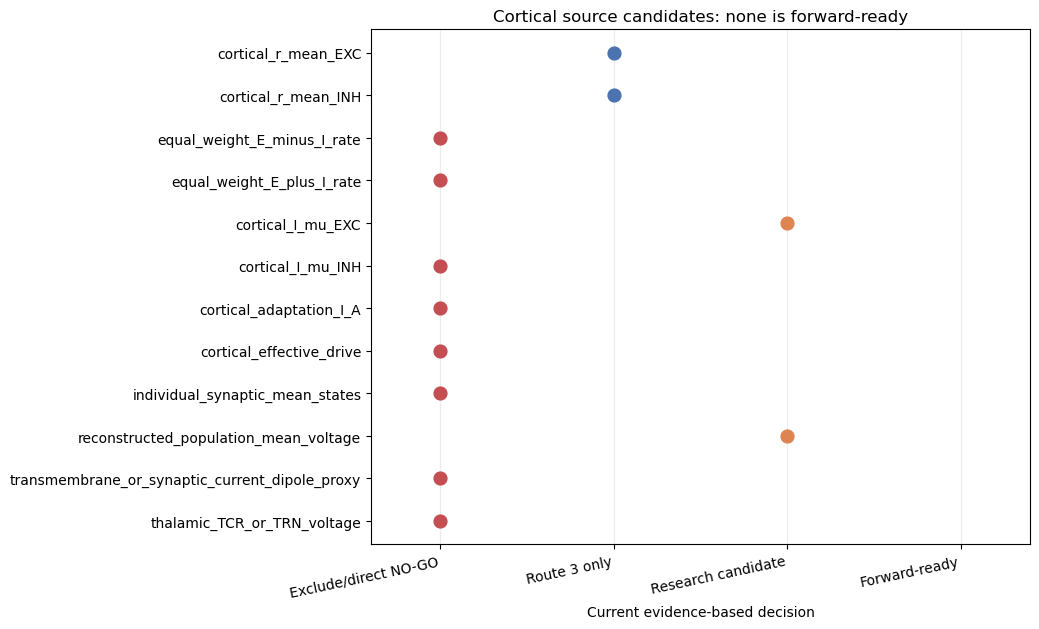

In [2]:
state_classification = pd.DataFrame([
    {
        "quantity": "r_mean_EXC / r_mean_INH",
        "code_class": "integrated state",
        "project_saved": True,
        "native_unit": "1/ms; project converts to Hz",
        "EEG_source_ready": False,
        "evidence": "aln.py state_variable_names; V7 output_vars",
    },
    {
        "quantity": "I_mu EXC/INH",
        "code_class": "integrated state",
        "project_saved": False,
        "native_unit": "mV/ms",
        "EEG_source_ready": False,
        "evidence": "aln.py:414-421,577-606",
    },
    {
        "quantity": "I_A EXC",
        "code_class": "integrated adaptation state",
        "project_saved": False,
        "native_unit": "pA",
        "EEG_source_ready": False,
        "evidence": "aln.py:414-421,535-547",
    },
    {
        "quantity": "synaptic mean/variance states",
        "code_class": "integrated states",
        "project_saved": False,
        "native_unit": "dimensionless/model-native",
        "EEG_source_ready": False,
        "evidence": "aln.py:414-421,539-556",
    },
    {
        "quantity": "population mean voltage",
        "code_class": "transfer-function intermediate",
        "project_saved": False,
        "native_unit": "mV",
        "EEG_source_ready": False,
        "evidence": "V_mean_ss and voltage_lookup, aln.py:234-246,344-357,534-537",
    },
    {
        "quantity": "TCR/TRN V",
        "code_class": "integrated thalamic states",
        "project_saved": False,
        "native_unit": "mV",
        "EEG_source_ready": False,
        "evidence": "thalamus.py:125-135,304-311",
    },
])
display(state_classification)

source_candidates = source_candidate_decisions()
assert source_candidates["candidate"].is_unique
display(source_candidates)

decision_category = []
for decision in source_candidates["decision"]:
    lowered = decision.lower()
    if "preferred candidate" in lowered or "research candidate" in lowered or "research audit" in lowered:
        decision_category.append("Research candidate")
    elif "route-3" in lowered:
        decision_category.append("Route 3 only")
    else:
        decision_category.append("Exclude/direct NO-GO")
source_plot = source_candidates.assign(decision_category=decision_category)
category_x = {"Exclude/direct NO-GO": 0, "Route 3 only": 1, "Research candidate": 2, "Forward-ready": 3}
colors = {
    "Exclude/direct NO-GO": "#c44e52",
    "Route 3 only": "#4c72b0",
    "Research candidate": "#dd8452",
    "Forward-ready": "#55a868",
}
fig, ax = plt.subplots(figsize=(10.5, 6.4))
y = np.arange(len(source_plot))
for yi, (_, row) in zip(y, source_plot.iterrows()):
    ax.scatter(category_x[row["decision_category"]], yi, s=85, color=colors[row["decision_category"]], zorder=3)
ax.set_yticks(y, source_plot["candidate"])
ax.set_xticks(list(category_x.values()), list(category_x.keys()), rotation=12, ha="right")
ax.set_xlim(-0.4, 3.4)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.set_title("Cortical source candidates: none is forward-ready")
ax.set_xlabel("Current evidence-based decision")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"source_candidate_decisions.{suffix}", dpi=180 if suffix == "png" else None, bbox_inches="tight")
display(fig)
plt.close(fig)


## 3. What neurolib's lead-field utility supplies, and what it assumes

`neurolib/utils/leadfield.py` wraps MNE. It can construct a
subject/template BEM, coregister sensor information, build a cortical
surface source space, compute a sensor-by-dipole forward matrix, fix
dipoles to surface-normal orientations and average columns into AAL2
regions.

It does **not** define which ALN variable is a current dipole, where
the single ALN node is located, its cortical extent/orientation, its
dipole-moment unit, or the Fpz-Cz reference/noise contract. The
official MNE API requires sensor `Info`, a head-to-MRI transform,
source space and BEM:
[MNE API](https://mne.tools/stable/generated/mne.make_forward_solution.html).


In [3]:
leadfield_requirements = leadfield_requirement_matrix()
assert not leadfield_requirements["provided_by_current_two_node_model"].any()
display(leadfield_requirements)

local_leadfield = Path(__import__("neurolib").__file__).resolve().parent / "utils" / "leadfield.py"
leadfield_code_check = {
    "local_file_exists": local_leadfield.exists(),
    "uses_mne_make_forward_solution": "mne.make_forward_solution" in local_leadfield.read_text(encoding="utf-8"),
    "uses_fixed_surface_orientation": "force_fixed=True" in local_leadfield.read_text(encoding="utf-8"),
    "implements_fpz_cz_reference": "Fpz-Cz" in local_leadfield.read_text(encoding="utf-8"),
    "implements_aln_state_to_dipole": "I_mu_EXC" in local_leadfield.read_text(encoding="utf-8"),
}
assert leadfield_code_check["local_file_exists"]
assert leadfield_code_check["uses_mne_make_forward_solution"]
assert not leadfield_code_check["implements_fpz_cz_reference"]
assert not leadfield_code_check["implements_aln_state_to_dipole"]
display(pd.DataFrame([leadfield_code_check]))


,requirement,leadfield_utility_use,provided_by_current_two_node_model,status,evidence
0,EEG sensor info and locations,MNE Raw/Info and montage,False,missing_model_mapping,leadfield.py:190-241
1,head-to-MRI transform,trans file for coregistration,False,missing,"leadfield.py:98-116,244-263"
2,cortical surface source space,dipole coordinates on cortical surface,False,missing,leadfield.py:158-188
3,dipole orientation,fixed surface-normal orientation after conversion,False,missing,leadfield.py:526-528
4,BEM surfaces and conductivities,three-layer EEG conductor model,False,missing_instance,leadfield.py:118-156
5,forward solution,sensor-by-dipole gain matrix,False,missing,leadfield.py:244-263
6,atlas NIfTI/XML,assign dipoles to AAL2 cortical regions,False,missing_instance,leadfield.py:488-553
7,node-to-atlas mapping,select/aggregate source columns for model nodes,False,missing,not defined in sleep_loop
8,source time series in dipole-moment units,multiply lead field by source amplitudes,False,missing,not implemented by leadfield.py
9,Fpz-Cz bipolar operator,subtract projected sensor potentials,False,missing_project_contract,not implemented by leadfield.py


,local_file_exists,uses_mne_make_forward_solution,uses_fixed_surface_orientation,implements_fpz_cz_reference,implements_aln_state_to_dipole
0,True,True,True,False,False


## 4. Single-source Fpz-Cz is temporally rank-1

For one scalar source \(q(t)\) and a linear instantaneous lead field:

\[
V_{\mathrm{Fpz}}(t)=L_{\mathrm{Fpz}}q(t), \qquad
V_{\mathrm{Cz}}(t)=L_{\mathrm{Cz}}q(t)
\]

\[
V_{\mathrm{Fpz-Cz}}(t)
=\left(L_{\mathrm{Fpz}}-L_{\mathrm{Cz}}\right)q(t).
\]

The bipolar signal may be non-zero when the two lead-field gains
differ, but it remains a fixed gain/sign copy of the same source.
Thus a fully declared single dipole could produce a physical
Fpz-Cz voltage, but the current abstract node supplies none of the
position, orientation or dipole-moment information needed to compute
that gain. It also cannot express distributed source mixtures that
alter channel-specific temporal or spectral structure.


,source_count,source_model,sensor_model,bipolar_model,temporal_rank,can_be_nonzero,nonzero_condition,adds_new_temporal_structure,scientific_consequence
0,1,q(t) is one scalar cortical source,V_Fpz(t)=L_Fpz*q(t); V_Cz(t)=L_Cz*q(t),V_Fpz-Cz(t)=(L_Fpz-L_Cz)*q(t),1,True,L_Fpz != L_Cz and q(t) is nonzero,False,"With one declared scalar source, Fpz-Cz is a f..."


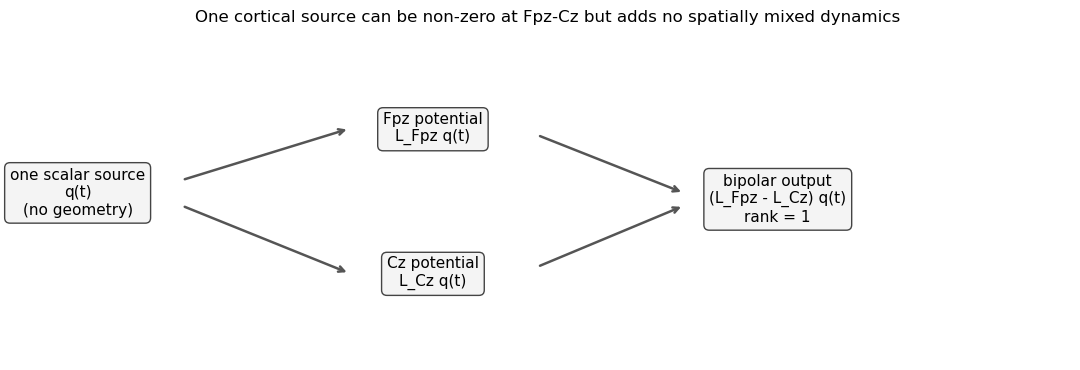

In [4]:
rank_audit = single_source_rank_audit()
assert rank_audit["temporal_rank"] == 1
assert rank_audit["adds_new_temporal_structure"] is False
display(pd.DataFrame([rank_audit]))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")
boxes = [
    (0.05, 0.52, "one scalar source\nq(t)\n(no geometry)"),
    (0.39, 0.72, "Fpz potential\nL_Fpz q(t)"),
    (0.39, 0.27, "Cz potential\nL_Cz q(t)"),
    (0.72, 0.50, "bipolar output\n(L_Fpz - L_Cz) q(t)\nrank = 1"),
]
for x, y0, label in boxes:
    ax.text(
        x,
        y0,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "#f4f4f4", "edgecolor": "#444444"},
    )
arrow = {"arrowstyle": "->", "color": "#555555", "lw": 1.8}
ax.annotate("", xy=(0.31, 0.72), xytext=(0.15, 0.56), xycoords="axes fraction", arrowprops=arrow)
ax.annotate("", xy=(0.31, 0.27), xytext=(0.15, 0.48), xycoords="axes fraction", arrowprops=arrow)
ax.annotate("", xy=(0.63, 0.52), xytext=(0.49, 0.70), xycoords="axes fraction", arrowprops=arrow)
ax.annotate("", xy=(0.63, 0.48), xytext=(0.49, 0.29), xycoords="axes fraction", arrowprops=arrow)
ax.set_title("One cortical source can be non-zero at Fpz-Cz but adds no spatially mixed dynamics", pad=12)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"single_source_rank1.{suffix}", dpi=180 if suffix == "png" else None, bbox_inches="tight")
display(fig)
plt.close(fig)


## 5. Strict measurement contract and leakage gate

The contract below follows the required chain
`theta -> dynamics -> cortical source -> geometry/orientation ->
lead field -> Fpz/Cz -> bipolar reference -> gain/noise -> 100 Hz ->
30 s epochs -> EEG extractor`.

Empty or arbitrary declarations are not repaired with defaults. In
particular, source choice, location, orientation, gain or noise must
not be selected by maximizing agreement with SC4001 and then reused
to infer SC4001; that would leak the inference target into the
measurement model.


,stage_index,component,required_definition,current_status,availability_class,evidence_or_owner,leakage_constraint,gate
0,1,theta,Eight model parameters with frozen bounds/order,Available,current_code,V7/V8 parameter files,Do not tune bounds on SC4001 fit outcomes,PASS
1,2,neurolib_dynamics,"Versioned ALN-cortex + thalamus equations, see...",Available,current_code,V7/V8 model modules and adapter,Freeze before any bank,PASS
2,3,declared_cortical_source,One explicitly defined primary source variable,No source approved,researcher_decision,Candidate matrix,Cannot select by best SC4001 spectral match,NO-GO
3,4,source_reconstruction,Deterministic state-to-source equation with ph...,Absent,literature_and_implementation,ALN exposes states but no dipole equation,Cannot fit arbitrary weights to SC4001,NO-GO
4,5,source_geometry_orientation,"Coordinates, patch extent, cortical-normal ori...",Absent,external_anatomy_and_researcher_decision,Two-node model has no coordinates/orientation,Do not choose location/orientation to maximize...,NO-GO
5,6,head_volume_conductor,"MRI/template geometry, conductivities, BEM and...",Generic utility only; no project instance,external_data_and_code,neurolib/utils/leadfield.py + MNE,Template choice must be declared before target...,NO-GO
6,7,lead_field,Versioned sensor-by-source gain matrix with fi...,Not generated for this model,reconstructable_after_4_to_6,MNE make_forward_solution,No target-conditioned sensor/source selection,NO-GO
7,8,sensor_potentials,Separate physical Fpz and Cz potentials before...,Absent,requires_lead_field,V = L q,Cannot estimate two gains from the same SC4001...,NO-GO
8,9,Fpz_minus_Cz_reference,Declared bipolar subtraction after sensor proj...,Operator known; inputs absent,partly_available,Observed channel label EEG Fpz-Cz,Reference operation must not be replaced by a ...,NO-GO
9,10,physical_gain_and_unit,Dipole moment to volts/uV without arbitrary fi...,Absent,external_calibration,No current project evidence,SC4001 target cannot calibrate gain for its ow...,NO-GO


,quantity,may_be_fixed_from_code,needs_literature,needs_researcher_decision,needs_external_calibration,using_sc4001_target_would_leak,acceptable_evidence
0,dynamics and theta order,True,False,True,False,True,versioned model/config before inference
1,cortical source variable,False,True,True,True,True,biophysical derivation plus independent valida...
2,source coordinates/extent/orientation,False,True,True,True,True,anatomical atlas/MRI independent of SC4001 out...
3,conductivity/BEM/template,False,True,True,False,False,pre-registered MNE/fsaverage or subject MRI co...
4,lead-field matrix,False,False,False,False,False,deterministic output after geometry and sensor...
5,Fpz-Cz reference,True,False,False,False,False,"explicit [1, -1] sensor operator"
6,source-to-dipole gain,False,True,True,True,True,independent EEG/MEG/LFP calibration or validat...
7,sensor/reference noise,False,True,True,True,True,independent N3 recordings or instrument model
8,100 Hz resampling,True,False,True,False,False,frozen anti-alias implementation
9,30 s epoch policy,True,False,True,False,False,same contract on real and simulated sensor vol...


Strict empty-contract gate: {'status': 'NO-GO', 'passed': False, 'missing_fields': ['source_variable', 'source_physical_definition', 'source_native_unit', 'source_to_dipole_model', 'dipole_moment_unit', 'source_coordinates_mri_mm', 'source_orientation_xyz', 'source_extent_or_patch_area', 'head_model_id', 'head_to_mri_transform_id', 'conductivity_model', 'leadfield_id', 'sensor_names', 'reference_operator', 'gain_calibration_id', 'sensor_noise_model_id', 'calibration_dataset_id', 'validation_dataset_id', 'calibration_independent_of_sc4001', 'validation_independent_of_sc4001', 'output_unit', 'resample_hz', 'epoch_duration_s'], 'invalid_fields': [], 'leakage_fields': ['calibration_independent_of_sc4001', 'validation_independent_of_sc4001'], 'warnings': []}
Projection refusal: EEG measurement contract is NO-GO: missing=['source_variable', 'source_physical_definition', 'source_native_unit', 'source_to_dipole_model', 'dipole_moment_unit', 'source_coordinates_mri_mm', 'source_orientation_xyz'

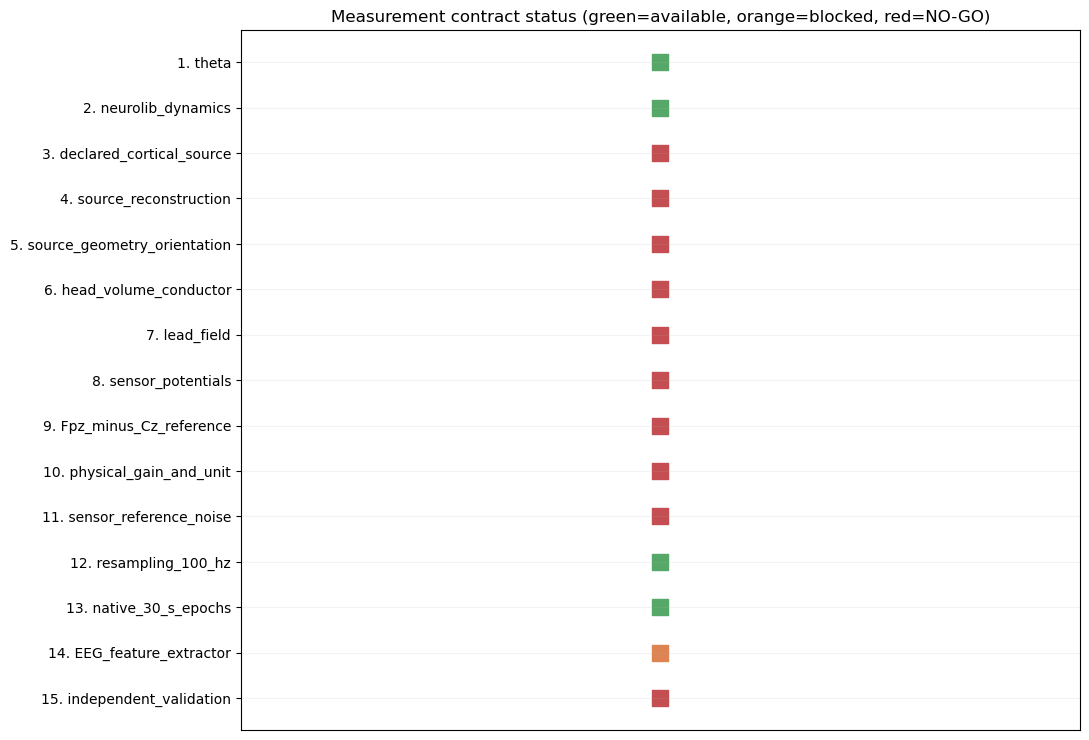

In [5]:
contract_components = measurement_contract_components()
leakage = calibration_leakage_matrix()
display(contract_components)
display(leakage)

empty_gate = validate_measurement_declaration({})
assert empty_gate.status == "NO-GO"
try:
    apply_measurement_model(np.ones(100), {})
except MeasurementContractError as exc:
    refusal_message = str(exc)
else:
    raise AssertionError("Incomplete measurement declaration was not refused")
print("Strict empty-contract gate:", empty_gate.as_dict())
print("Projection refusal:", refusal_message)

gate_color = {"PASS": "#55a868", "BLOCKED": "#dd8452", "NO-GO": "#c44e52"}
fig, ax = plt.subplots(figsize=(11, 7.5))
y = np.arange(len(contract_components))
for yi, gate in zip(y, contract_components["gate"]):
    ax.scatter(0, yi, s=130, marker="s", color=gate_color[gate])
ax.set_yticks(y, [f"{i}. {name}" for i, name in zip(contract_components["stage_index"], contract_components["component"])])
ax.set_xticks([])
ax.set_xlim(-0.5, 0.5)
ax.invert_yaxis()
ax.set_title("Measurement contract status (green=available, orange=blocked, red=NO-GO)")
ax.grid(axis="y", alpha=0.15)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"measurement_contract_status.{suffix}", dpi=180 if suffix == "png" else None, bbox_inches="tight")
display(fig)
plt.close(fig)


## 6. Route 2 versus Route 3

**Route 2** remains scientifically possible in principle, but is not
implementable from the current two-node state alone. It requires new,
independently constrained source geometry and source-to-dipole
assumptions plus held-out measurement validation.

**Route 3** restricts inference to a declared cortical-observable
simulator space. It can test synthetic parameter recovery and
calibration, but cannot claim inference about real Fpz-Cz physiology.
Recommending Route 3 for the near-term conference scope does not
authorize a bank or SNPE run; those remain researcher decisions.


In [6]:
routes = route_decision_matrix()
citations = citation_table()
display(routes)
display(citations)

decision = {
    "schema_version": SCHEMA_VERSION,
    "current_model_supports_physically_declared_fpz_cz": False,
    "single_source_can_be_nonzero": True,
    "single_source_temporal_rank": 1,
    "existing_validated_eeg_or_lfp_proxy": False,
    "existing_project_forward_model": False,
    "route_2_current_status": "NO-GO_PENDING_EXTERNAL_SOURCE_AND_SPATIAL_ASSUMPTIONS",
    "route_2_long_term_status": "scientifically_possible_if_independently_defined_and_validated",
    "near_term_recommendation": "Route 3 synthetic cortical-observable recovery, with real EEG limited to external shape-level validation",
    "route_3_authorized": False,
    "simulation_bank_authorized": False,
    "pilot_snpe_authorized": False,
    "conference_claim_boundary": (
        "Report model dynamics, adapter engineering, shape-level external comparisons, and the explicit "
        "measurement-model limitation. Do not claim a real-EEG posterior or measurement validation."
    ),
    "researcher_decisions_required": [
        "Choose near-term Route 3 scope versus investing in a Route 2 source/forward program.",
        "For Route 2, approve a biophysically defined source variable and independent calibration/validation datasets.",
        "For Route 3, freeze the cortical observable, prior, extractor, diagnostics, and budget before any bank or SNPE run.",
    ],
}
display(pd.DataFrame([decision]))


,criterion,route_2_measurement_model,route_3_synthetic_observable,current_assessment
0,scientific_claim,Inference about theta conditional on a validat...,Parameter recovery for a declared model-intern...,Route 2 is stronger but unsupported now
1,required_implementation,"Source reconstruction, geometry, BEM/lead fiel...","Freeze model observable, simulator extractor, ...",Route 3 is implementable sooner
2,required_external_data,Anatomy/template plus independent measurement-...,None for synthetic recovery; real EEG only opt...,Route 2 lacks essential external evidence
3,calibration_leakage_risk,High if source/gain/noise are tuned on SC4001,Low if real EEG is excluded from tuning,Route 3 has cleaner immediate separation
4,identifiability,"theta is confounded with source weights, geome...",Identifiability of theta can be measured withi...,Route 2 currently underidentified
5,expected_time_cost,"High: source derivation, forward implementatio...",Moderate: honest simulator-bank and recovery s...,Conference horizon favors Route 3
6,conference_suitability,Only as a feasibility/limitations discussion u...,Suitable as a scoped synthetic-method result,Recommend Route 3 for near-term claims
7,can_claim,Current work can claim a documented feasibilit...,Can later claim synthetic recovery/calibration...,Neither route currently has posterior results
8,cannot_claim,No current real-EEG posterior or EEG measureme...,No inference about real Fpz-Cz physiology or p...,Keep modality boundary explicit
9,minimum_go_no_go,All contract stages pass and held-out measurem...,"Frozen observable/schema, fixed finite extract...",Both remain researcher-gated


,citation,title,used_for,url,source_type
0,Cakan and Obermayer 2020,Biophysically grounded mean-field models of ne...,ALN model meaning and transfer-function context,https://doi.org/10.1371/journal.pcbi.1007822,peer_reviewed_model_paper
1,MNE make_forward_solution,mne.make_forward_solution official API,"Required sensor Info, transform, source space ...",https://mne.tools/stable/generated/mne.make_fo...,official_documentation
2,MNE forward tutorial,Head model and forward computation,"Coregistration, source space, three-layer EEG ...",https://mne.tools/stable/auto_tutorials/forwar...,official_documentation
3,Hallez et al. 2007,Review on solving the forward problem in EEG s...,"Dipole position/orientation, conductivity and ...",https://pmc.ncbi.nlm.nih.gov/articles/PMC2234413/,peer_reviewed_review
4,Mosher et al. 1999,EEG and MEG: forward solutions for inverse met...,Lead-field factorization and differential EEG ...,https://pubmed.ncbi.nlm.nih.gov/10097460/,peer_reviewed_review


,schema_version,current_model_supports_physically_declared_fpz_cz,single_source_can_be_nonzero,single_source_temporal_rank,existing_validated_eeg_or_lfp_proxy,existing_project_forward_model,route_2_current_status,route_2_long_term_status,near_term_recommendation,route_3_authorized,simulation_bank_authorized,pilot_snpe_authorized,conference_claim_boundary,researcher_decisions_required
0,forward-model-feasibility-v0.1,False,True,1,False,False,NO-GO_PENDING_EXTERNAL_SOURCE_AND_SPATIAL_ASSU...,scientifically_possible_if_independently_defin...,Route 3 synthetic cortical-observable recovery...,False,False,False,"Report model dynamics, adapter engineering, sh...",[Choose near-term Route 3 scope versus investi...


## 7. Export, reload, and immutable-source verification

Artifacts contain tables, decisions and provenance only. They do not
contain raw EEG, simulator time series, a simulation bank or
posterior samples. Every file is reloaded before the notebook ends,
and notebooks 01-08 are re-hashed.


In [7]:
tables = {
    "source_candidate_decisions.csv": source_candidates,
    "state_classification.csv": state_classification,
    "leadfield_requirements.csv": leadfield_requirements,
    "measurement_contract_components.csv": contract_components,
    "calibration_leakage_matrix.csv": leakage,
    "route2_route3_decision.csv": routes,
    "literature_sources.csv": citations,
}
for name, frame in tables.items():
    frame.to_csv(OUTPUT_DIR / name, index=False)

json_artifacts = {
    "environment_report.json": environment,
    "single_source_rank_audit.json": rank_audit,
    "forward_model_feasibility_decision.json": decision,
    "protected_notebook_hashes.json": protected_hashes_start,
}
for name, payload in json_artifacts.items():
    (OUTPUT_DIR / name).write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")

reload_checks = {}
for name, frame in tables.items():
    loaded = pd.read_csv(OUTPUT_DIR / name)
    reload_checks[name] = {
        "readable": True,
        "rows": int(len(loaded)),
        "columns": int(len(loaded.columns)),
        "shape_matches": loaded.shape == frame.shape,
    }
    assert loaded.shape == frame.shape
for name in json_artifacts:
    loaded = json.loads((OUTPUT_DIR / name).read_text(encoding="utf-8"))
    reload_checks[name] = {"readable": True, "top_level_keys": len(loaded)}

protected_hashes_end = {
    path.relative_to(PROJECT_ROOT).as_posix(): sha256(path)
    for path in protected_paths
}
assert protected_hashes_end == protected_hashes_start
nbformat.validate(nbformat.read(NOTEBOOK_PATH, as_version=4))

validation = {
    "schema_version": SCHEMA_VERSION,
    "nbformat_validation": "PASS",
    "protected_notebook_hashes_unchanged": True,
    "artifact_reload": reload_checks,
    "route_2_gate": decision["route_2_current_status"],
    "simulation_run_count": 0,
    "simulation_bank_created": False,
    "snpe_started": False,
    "raw_eeg_saved": False,
    "raw_simulator_signal_saved": False,
}
(OUTPUT_DIR / "validation_report.json").write_text(
    json.dumps(validation, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print("Artifact reload: PASS")
print("Protected notebooks 01-08 unchanged: PASS")
print("Route 2 gate:", validation["route_2_gate"])


Artifact reload: PASS
Protected notebooks 01-08 unchanged: PASS
Route 2 gate: NO-GO_PENDING_EXTERNAL_SOURCE_AND_SPATIAL_ASSUMPTIONS


## 8. Decision summary

1. The current single cortical node does not by itself support a
   spatially non-degenerate Fpz-Cz measurement model.
2. A fully specified single dipole could yield a non-zero bipolar
   voltage, but only as a rank-1 scaled copy and only after external
   position, orientation, source-moment and head-model assumptions.
3. Reconstructed ALN population mean voltage is the best-supported
   voltage-level research candidate, but it is not a primary-current
   dipole and remains insufficient.
4. A derived transmembrane/synaptic-current dipole would be more
   relevant to Route 2, but it does not currently exist with
   traceable units, population geometry or validation.
5. Near-term conference claims should use Route 3 scope or retain
   real EEG as external shape-level validation. No simulation bank
   or SNPE is authorized by this notebook.
